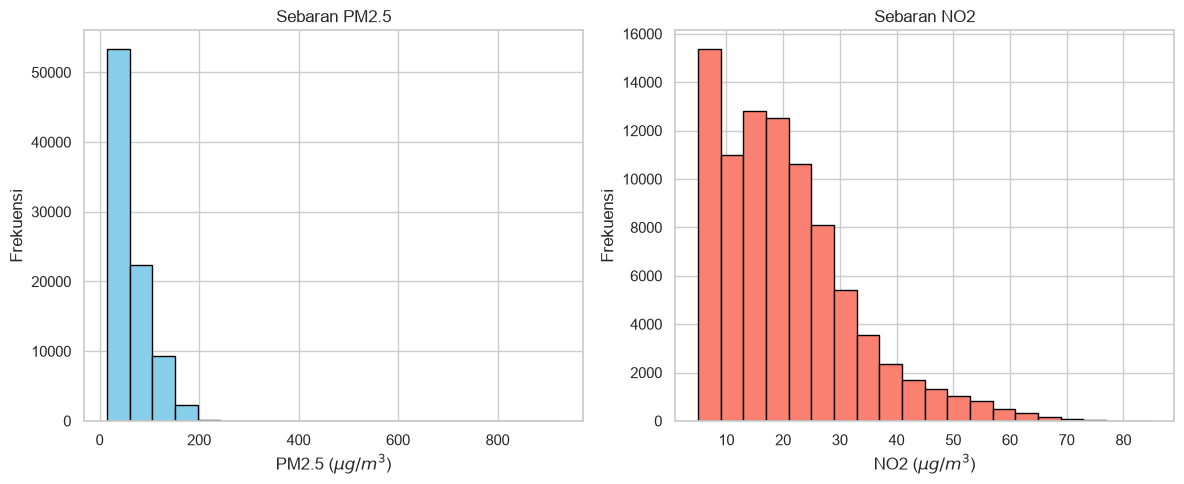

In [15]:
# Grafik 1 (Sebaran PM25 dan Sebaran NO2)

import pandas as pd
import matplotlib.pyplot as plt

# Membaca file dataset CSV dan menyimpannya ke dalam variabel DataFrame 'df'
df = pd.read_csv('data/air_quality.csv')

# Mengubah kolom 'datetime' menjadi format waktu (datetime) agar bisa diekstrak
df['datetime'] = pd.to_datetime(df['datetime'])
# Mengambil nilai tahun saja dari kolom datetime dan menyimpannya ke kolom baru 'tahun'
df['tahun'] = df['datetime'].dt.year

# Menyiapkan kanvas atau area gambar dengan ukuran lebar 12 inci dan tinggi 5 inci
plt.figure(figsize=(12, 5))

# SUBPLOT 1: HISTOGRAM PM2.5 (Grafik Sebelah Kiri)

plt.subplot(1, 2, 1) # Membagi kanvas jadi 1 baris, 2 kolom, dan aktifkan kotak pertama
plt.hist(df['pm25'], bins=20, color='skyblue', edgecolor='black') # Membuat histogram dengan 20 batang
plt.title("Sebaran PM2.5") # Memberikan judul grafik
plt.xlabel("PM2.5 ($\mu g/m^3$)") # Memberikan label sumbu X beserta satuannya
plt.ylabel("Frekuensi") # Memberikan label sumbu Y (jumlah kemunculan data)

# SUBPLOT 2: HISTOGRAM NO2 (Grafik Sebelah Kanan)

plt.subplot(1, 2, 2) # Mengaktifkan kotak kedua pada kanvas
plt.hist(df['no2'], bins=20, color='salmon', edgecolor='black') # Membuat histogram NO2
plt.title("Sebaran NO2") # Memberikan judul grafik
plt.xlabel("NO2 ($\mu g/m^3$)") # Memberikan label sumbu X beserta satuannya
plt.ylabel("Frekuensi") # Memberikan label sumbu Y

# Merapikan tata letak grafik agar tidak saling bertumpuk
plt.tight_layout()
# Perintah untuk menampilkan hasil gambar grafik ke layar
plt.show()

Sebaran data untuk konsentrasi PM2.5 dan NO2 berbentuk miring ke kanan (right-skewed), di mana frekuensi terbanyak terkonsentrasi pada nilai rendah di sebelah kiri, sementara terdapat ekor panjang yang menunjukkan adanya nilai-nilai tinggi yang ekstrem.

PERHITUNGAN ATURAN 1,5 x IQR PER TAHUN
Tahun 2015:
  Q1 = 30.95 | Q3 = 106.42 | IQR = 75.47
  Batas normal = [-82.25, 219.62] µg/m³
  Jumlah pencilan = 38 data

Tahun 2016:
  Q1 = 28.52 | Q3 = 102.78 | IQR = 74.26
  Batas normal = [-82.88, 214.18] µg/m³
  Jumlah pencilan = 28 data

Tahun 2017:
  Q1 = 28.22 | Q3 = 97.88 | IQR = 69.65
  Batas normal = [-76.26, 202.36] µg/m³
  Jumlah pencilan = 32 data

Tahun 2018:
  Q1 = 27.01 | Q3 = 93.22 | IQR = 66.21
  Batas normal = [-72.31, 192.53] µg/m³
  Jumlah pencilan = 45 data

Tahun 2019:
  Q1 = 24.91 | Q3 = 89.88 | IQR = 64.97
  Batas normal = [-72.54, 187.33] µg/m³
  Jumlah pencilan = 33 data

Tahun 2020:
  Q1 = 15.00 | Q3 = 51.84 | IQR = 36.84
  Batas normal = [-40.26, 107.10] µg/m³
  Jumlah pencilan = 93 data

Tahun 2021:
  Q1 = 20.27 | Q3 = 76.10 | IQR = 55.83
  Batas normal = [-63.48, 159.84] µg/m³
  Jumlah pencilan = 47 data

Tahun 2022:
  Q1 = 19.21 | Q3 = 72.83 | IQR = 53.61
  Batas normal = [-61.20, 153.24] µg/m³
  Jumlah pencilan = 

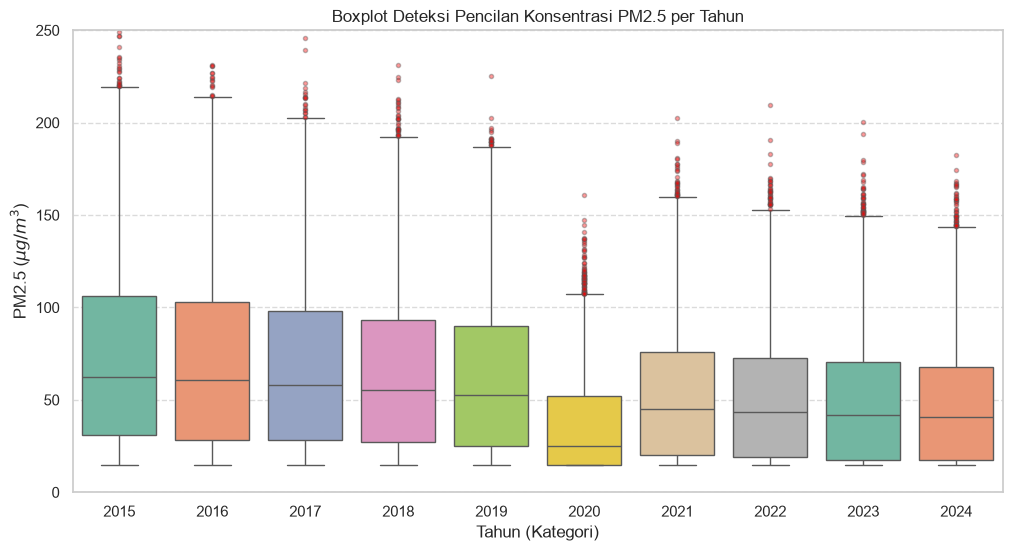

In [25]:
# ==========================================
# BOXPLOT: Deteksi Pencilan (Outlier) PM2.5 per Tahun
# ==========================================

import seaborn as sns

# --------------------------------------------------
# 1. Hitung Q1, Q3, IQR, dan batas pencilan PER TAHUN
#    (dilakukan SEBELUM menggambar grafik, agar terpisah
#     jelas antara "hitung statistik" dan "buat visual")
# --------------------------------------------------
print("=" * 55)
print("PERHITUNGAN ATURAN 1,5 x IQR PER TAHUN")
print("=" * 55)

for tahun, kelompok in df.groupby('tahun')['pm25']:
    q1 = kelompok.quantile(0.25)
    q3 = kelompok.quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    jumlah_outlier = ((kelompok < batas_bawah) | (kelompok > batas_atas)).sum()

    print(f"Tahun {tahun}:")
    print(f"  Q1 = {q1:.2f} | Q3 = {q3:.2f} | IQR = {iqr:.2f}")
    print(f"  Batas normal = [{batas_bawah:.2f}, {batas_atas:.2f}] µg/m³")
    print(f"  Jumlah pencilan = {jumlah_outlier} data\n")

# --------------------------------------------------
# 2. Gambar boxplot per tahun
# --------------------------------------------------
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='tahun', y='pm25', hue='tahun', palette='Set2', legend=False,
            flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.4))

plt.title("Boxplot Deteksi Pencilan Konsentrasi PM2.5 per Tahun")
plt.xlabel("Tahun (Kategori)")
plt.ylabel("PM2.5 ($\\mu g/m^3$)")
plt.ylim(0, 250)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Dengan membatasi visualisasi pada rentang nilai 0 hingga 250, terlihat jelas bahwa setiap tahunnya terdapat banyak sekali titik pencilan (outliers) merah yang melewati batas 1,5 x IQR , menunjukkan konsistensi anomali polusi tinggi di atas batas normal.
Khusus pada tahun 2020, kotak distribusi tidak memiliki kumis bawah (lower whisker). Hal ini terjadi secara statistik karena nilai Kuartil 1 (Q1) pada tahun tersebut menyentuh batas minimum absolut data (15,0 µg/m³), sehingga batas bawah kotak berimpit langsung dengan titik data terendah.

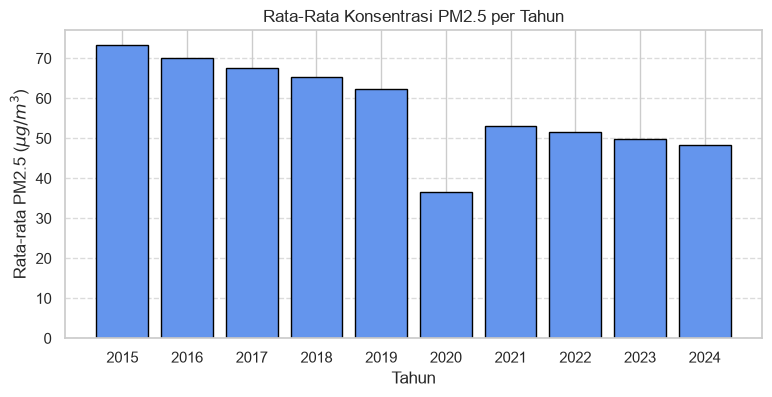

In [21]:
# 3. DIAGRAM BATANG (Rata-rata PM2.5 per Tahun)

# Menghitung rata-rata (mean) PM2.5 dikelompokkan berdasarkan tahun
rata_pm25 = df.groupby('tahun')['pm25'].mean()

plt.figure(figsize=(9, 4))

# Membuat diagram batang dengan warna biru medium dan garis tepi hitam
plt.bar(rata_pm25.index.astype(str), rata_pm25.values, color='cornflowerblue', edgecolor='black')

plt.title('Rata-Rata Konsentrasi PM2.5 per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata PM2.5 ($\mu g/m^3$)')

# Menampilkan grid tipis di sumbu Y agar mudah membaca nilainya
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Grafik rata-rata memperlihatkan fluktuasi tingkat polusi PM2.5 per tahun secara dinamis, di mana tahun 2020 mencatatkan penurunan tingkat polusi terendah secara rata-rata.

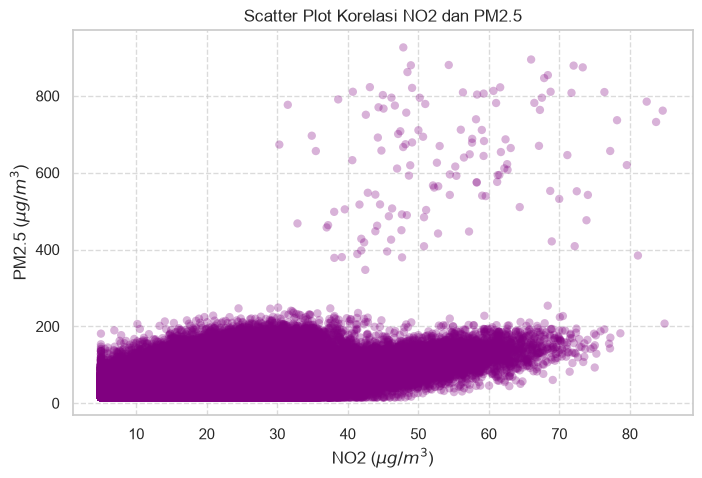


--- Nilai Plus: Median PM2.5 Berdasarkan Tahun ---
tahun
2015    62.169379
2016    60.496060
2017    57.890065
2018    55.273548
2019    52.706629
2020    25.260007
2021    44.965782
2022    43.648586
2023    41.814283
2024    40.574355
Name: pm25, dtype: float64


In [26]:
# Scatter Plot & Perbandingan Statistik Antarkategori

# A. Scatter Plot dua kolom numerik (NO2 dan PM2.5)
plt.figure(figsize=(8, 5))
plt.scatter(df['no2'], df['pm25'], alpha=0.3, color='purple', edgecolors='none')
plt.title("Scatter Plot Korelasi NO2 dan PM2.5")
plt.xlabel("NO2 ($\mu g/m^3$)")
plt.ylabel("PM2.5 ($\mu g/m^3$)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# B. Perbandingan statistik median PM2.5 antarkategori (Tahun)
print("\n--- Nilai Plus: Median PM2.5 Berdasarkan Tahun ---")
print(df.groupby("tahun")["pm25"].median())

Terdapat korelasi positif antara kadar NO2 dan PM2.5, di mana peningkatan konsentrasi 
NO2 umumnya diikuti oleh kenaikan tingkat PM2.5.

Dari perbandingan median per tahun, terlihat bahwa median PM2.5 tertinggi terjadi pada 
tahun 2015, sedangkan terendah pada tahun 2024 — pola ini konsisten dengan tren yang 
terlihat pada diagram batang rata-rata sebelumnya, mengindikasikan bahwa median cukup 
mewakili kondisi umum polusi tiap tahun tanpa terlalu dipengaruhi oleh nilai ekstrem/outlier.